In [1]:
# Evaluation — Multi-run Leaderboard & Plots (no bootstrap)

# This notebook:
# 1) Discovers completed runs under `/work/runs/` (must contain `metrics_dual.json`).  
# 2) **Filters BM25** runs to include **only** `bm25_unigram` and `bm25_unibigram`.  
# 3) Loads metrics into a unified dataframe.  
# 4) Renders **leaderboard tables** and **paper-ready plots** (item & parent metrics; # numeric split).  
# 5) Writes CSV/JSON artifacts to `/work/eval/`.

# > Relies on artifacts produced by your retrieval and metrics workflows.

In [2]:
## Config
# - Change paths if your repo uses a different layout.
# - `ALLOWED_BM25` enforces that only the canonical BM25 models are evaluated here.

from pathlib import Path
import json, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Paths ---
RUNS_ROOT = Path("/work/runs")
EVAL_OUT  = Path("/work/eval")
EVAL_OUT.mkdir(parents=True, exist_ok=True)

# --- BM25 filter ---
ALLOWED_BM25 = {"bm25_unigram", "bm25_unibigram"}  # only these among BM25 variants

print("RUNS_ROOT:", RUNS_ROOT)
print("EVAL_OUT :", EVAL_OUT)
print("ALLOWED_BM25:", ALLOWED_BM25)

RUNS_ROOT: /work/runs
EVAL_OUT : /work/eval
ALLOWED_BM25: {'bm25_unigram', 'bm25_unibigram'}


In [3]:
## Discovery helpers
# We scan `/work/runs/<method>/metrics_dual.json`.  
# BM25 runs are included **only** if the run folder name is in `ALLOWED_BM25`.
def _metrics_dual_path(run_dir: Path) -> Path:
    return run_dir / "metrics_dual.json"

def _is_selected_bm25(method_name: str, allowed_set) -> bool:
    return method_name.lower() in {m.lower() for m in allowed_set}

def _should_include(method_name: str, allowed_bm25) -> bool:
    name = method_name.lower()
    if name.startswith("bm25"):
        return _is_selected_bm25(name, allowed_bm25)
    return True  # include non-BM25 by default

def discover_runs(runs_root: Path, allowed_bm25) -> dict:
    runs = {}
    if not runs_root.exists():
        return runs
    for sub in runs_root.iterdir():
        if not sub.is_dir():
            continue
        method = sub.name  # /work/runs/<method>
        md = _metrics_dual_path(sub)
        if not md.exists():
            continue
        if _should_include(method, allowed_bm25):
            runs[method] = sub
    return dict(sorted(runs.items()))

runs = discover_runs(RUNS_ROOT, ALLOWED_BM25)
print(f"Selected runs ({len(runs)}):")
for k,v in runs.items():
    print(" -", k, "->", v)

Selected runs (6):
 - bm25_unigram -> /work/runs/bm25_unigram
 - tfidf_char_3_5 -> /work/runs/tfidf_char_3_5
 - tfidf_unigram -> /work/runs/tfidf_unigram
 - tfidf_unigram_nostop -> /work/runs/tfidf_unigram_nostop
 - tfidf_unigram_phrases_add -> /work/runs/tfidf_unigram_phrases_add
 - tfidf_unigram_phrases_replace -> /work/runs/tfidf_unigram_phrases_replace


In [4]:
## Load metrics
# We use the `metrics_dual.json` file saved by the per-method evaluation to build a unified dataframe.
def load_metrics_dual(method: str, run_dir: Path) -> pd.DataFrame:
    p = run_dir / "metrics_dual.json"
    with open(p, "r", encoding="utf-8") as f:
        data = json.load(f)
    df = pd.DataFrame(data)
    # Ensure standard columns
    std_cols = ["method","target","scope","queries","Acc@1","Recall@5","Recall@10","MRR","nDCG@10"]
    if "method" not in df.columns:
        df["method"] = method
    for col in std_cols:
        if col not in df.columns:
            df[col] = None
    df = df[std_cols]
    # Sort for display
    order = {"overall":0, "has_numbers":1, "no_numbers":2}
    df["__scope_order__"] = df["scope"].map(order).fillna(99)
    df = df.sort_values(["target","__scope_order__","method"]).drop(columns="__scope_order__")
    return df

frames = []
for m, p in runs.items():
    try:
        frames.append(load_metrics_dual(m, p))
    except Exception as e:
        print(f"[WARN] Failed to load {m}: {e}")

if frames:
    df_metrics = pd.concat(frames, ignore_index=True)
else:
    df_metrics = pd.DataFrame(columns=["method","target","scope","queries","Acc@1","Recall@5","Recall@10","MRR","nDCG@10"])

print("Loaded rows:", len(df_metrics))
display(df_metrics.head(10))
# Save the raw merged table
df_metrics.to_csv(EVAL_OUT / "all_metrics_dual_merged.csv", index=False)
df_metrics.to_json(EVAL_OUT / "all_metrics_dual_merged.json", orient="records", indent=2, force_ascii=False)
print("Saved merged metrics to", EVAL_OUT)

Loaded rows: 36


,method,target,scope,queries,Acc@1,Recall@5,Recall@10,MRR,nDCG@10
0,bm25_unigram,item,overall,5000.0,0.782800,0.877600,0.909200,0.825581,0.843079
1,bm25_unigram,item,has_numbers,4990.0,0.783166,0.877956,0.909218,0.825866,0.843310
2,bm25_unigram,item,no_numbers,10.0,0.600000,0.700000,0.900000,0.683036,0.727973
3,bm25_unigram,parent,overall,5000.0,0.888800,0.924800,0.946000,0.905796,0.876393
4,bm25_unigram,parent,has_numbers,4990.0,0.888577,0.924649,0.945892,0.905608,0.876146
5,bm25_unigram,parent,no_numbers,10.0,1.000000,1.000000,1.000000,1.000000,1.000000
6,tfidf_char_3_5,item,overall,5000.0,0.558200,0.622000,0.643000,0.586061,0.596658
7,tfidf_char_3_5,item,has_numbers,4990.0,0.557315,0.621242,0.642285,0.585232,0.595849
8,tfidf_char_3_5,item,no_numbers,10.0,1.000000,1.000000,1.000000,1.000000,1.000000
9,tfidf_char_3_5,parent,overall,5000.0,0.750400,0.794200,0.883200,0.782817,0.746685


Saved merged metrics to /work/eval


In [5]:
## Leaderboard tables (Overall)
# Paper-ready tables summarizing item- and parent-level metrics for the **Overall** scope.
def leaderboard(df: pd.DataFrame, target: str) -> pd.DataFrame:
    d = (df[(df["target"]==target) & (df["scope"].str.lower()=="overall")]
          .copy())
    cols = ["method","queries","Acc@1","Recall@5","Recall@10","MRR","nDCG@10"]
    d = d[cols].sort_values(["Acc@1","MRR","nDCG@10"], ascending=False).reset_index(drop=True)
    return d

lb_item   = leaderboard(df_metrics, target="item")
lb_parent = leaderboard(df_metrics, target="parent")

print("Item-level leaderboard (Overall)")
display(lb_item.style.format({"Acc@1":"{:.3f}","Recall@5":"{:.3f}","Recall@10":"{:.3f}","MRR":"{:.3f}","nDCG@10":"{:.3f}"}))
print("Parent-level leaderboard (Overall)")
display(lb_parent.style.format({"Acc@1":"{:.3f}","Recall@5":"{:.3f}","Recall@10":"{:.3f}","MRR":"{:.3f}","nDCG@10":"{:.3f}"}))

# Save
lb_item.to_csv(EVAL_OUT / "leaderboard_item_overall.csv", index=False)
lb_parent.to_csv(EVAL_OUT / "leaderboard_parent_overall.csv", index=False)

Item-level leaderboard (Overall)


,method,queries,Acc@1,Recall@5,Recall@10,MRR,nDCG@10
0,bm25_unigram,5000.000000,0.783,0.878,0.909,0.826,0.843
1,tfidf_unigram_phrases_replace,5000.000000,0.704,0.828,0.843,0.755,0.775
2,tfidf_unigram_phrases_add,5000.000000,0.649,0.848,0.922,0.735,0.777
3,tfidf_unigram_nostop,5000.000000,0.643,0.756,0.822,0.693,0.719
4,tfidf_unigram,5000.000000,0.630,0.751,0.803,0.686,0.708
5,tfidf_char_3_5,5000.000000,0.558,0.622,0.643,0.586,0.597


Parent-level leaderboard (Overall)


,method,queries,Acc@1,Recall@5,Recall@10,MRR,nDCG@10
0,tfidf_unigram_phrases_replace,5000.000000,0.990,0.990,0.990,0.990,0.972
1,tfidf_unigram_nostop,5000.000000,0.985,0.987,0.988,0.986,0.976
2,tfidf_unigram,5000.000000,0.947,0.975,0.984,0.957,0.944
3,tfidf_unigram_phrases_add,5000.000000,0.940,0.984,0.990,0.957,0.829
4,bm25_unigram,5000.000000,0.889,0.925,0.946,0.906,0.876
5,tfidf_char_3_5,5000.000000,0.750,0.794,0.883,0.783,0.747


In [6]:
## Numeric vs non-numeric splits (Item-level)
# We pivot the **item-level** metrics to compare *Has numbers* vs *No numbers* across methods.
def numeric_split_table(df: pd.DataFrame, metric: str = "Acc@1") -> pd.DataFrame:
    d = df[(df["target"]=="item") & (df["scope"].isin(["has_numbers","no_numbers"]))].copy()
    d["scope"] = d["scope"].replace({"has_numbers":"Has numbers", "no_numbers":"No numbers"})
    pivot = d.pivot_table(index="method", columns="scope", values=metric, aggfunc="first")
    pivot = pivot.reindex(lb_item["method"])  # align to leaderboard order
    return pivot

tbl_acc1 = numeric_split_table(df_metrics, "Acc@1")
tbl_recall10 = numeric_split_table(df_metrics, "Recall@10")
display(tbl_acc1.style.format("{:.3f}").set_caption("Item-level Acc@1 — Numeric vs No-numeric"))
display(tbl_recall10.style.format("{:.3f}").set_caption("Item-level Recall@10 — Numeric vs No-numeric"))

tbl_acc1.to_csv(EVAL_OUT / "numeric_split_item_acc1.csv")
tbl_recall10.to_csv(EVAL_OUT / "numeric_split_item_recall10.csv")

scope,Has numbers,No numbers
method,,
bm25_unigram,0.783,0.600
tfidf_unigram_phrases_replace,0.703,1.000
tfidf_unigram_phrases_add,0.648,1.000
tfidf_unigram_nostop,0.643,1.000
tfidf_unigram,0.629,1.000
tfidf_char_3_5,0.557,1.000


scope,Has numbers,No numbers
method,,
bm25_unigram,0.909,0.900
tfidf_unigram_phrases_replace,0.843,1.000
tfidf_unigram_phrases_add,0.921,1.000
tfidf_unigram_nostop,0.821,1.000
tfidf_unigram,0.803,1.000
tfidf_char_3_5,0.642,1.000


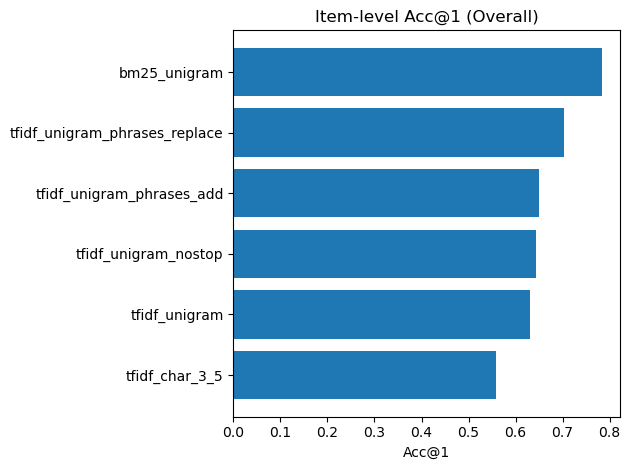

Saved plot: /work/eval/plot_item_acc1.png


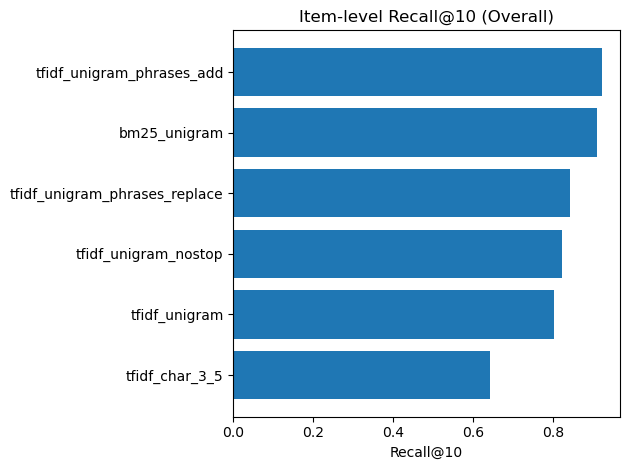

Saved plot: /work/eval/plot_item_recall10.png


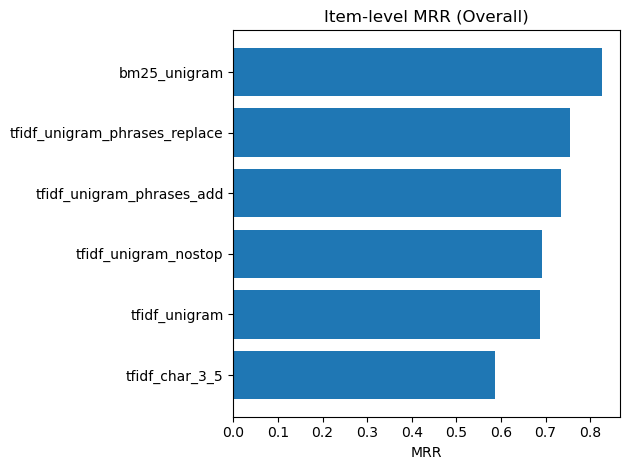

Saved plot: /work/eval/plot_item_mrr.png


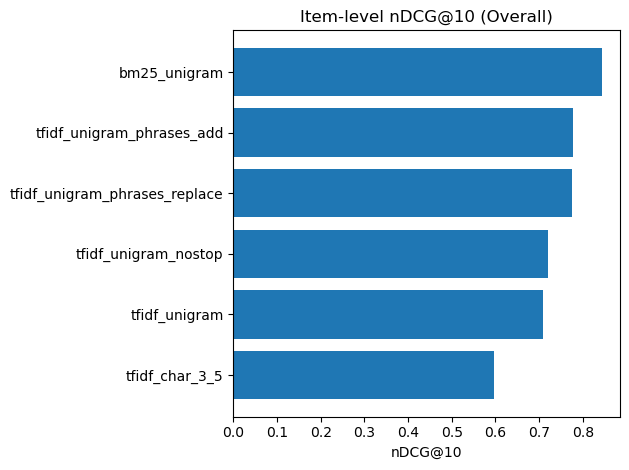

Saved plot: /work/eval/plot_item_ndcg10.png


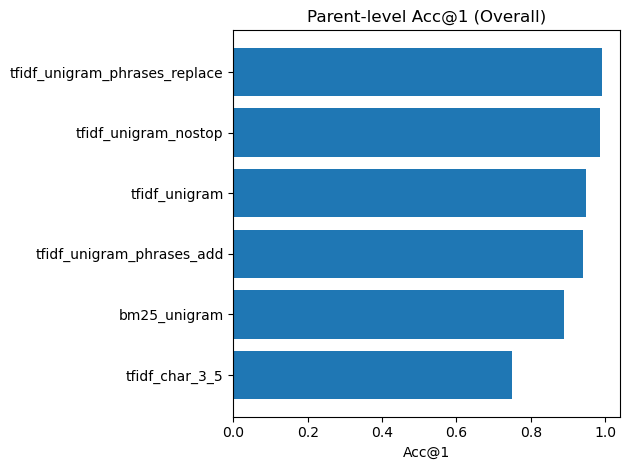

Saved plot: /work/eval/plot_parent_acc1.png


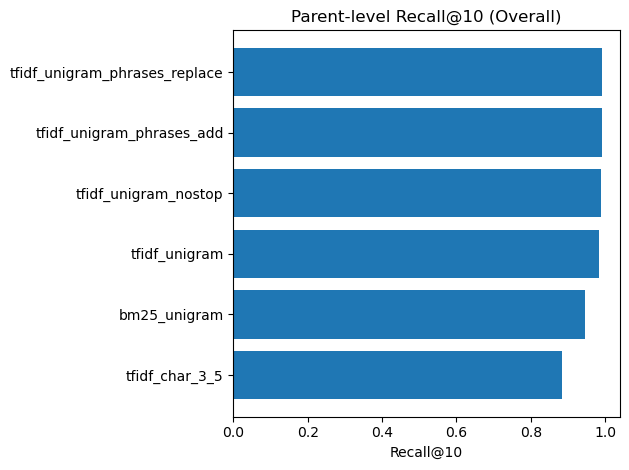

Saved plot: /work/eval/plot_parent_recall10.png


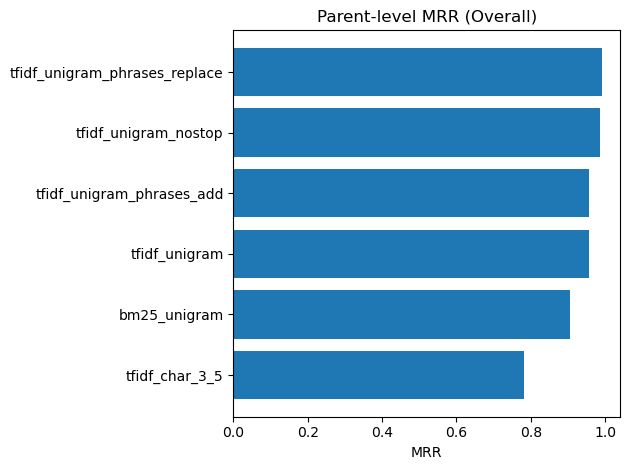

Saved plot: /work/eval/plot_parent_mrr.png


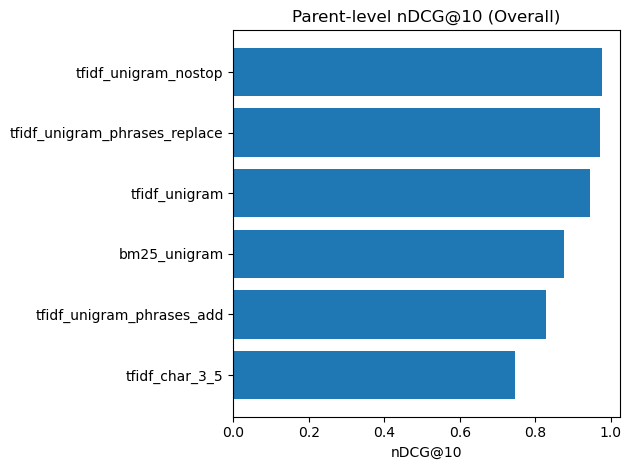

Saved plot: /work/eval/plot_parent_ndcg10.png


In [7]:
## Plots (paper-ready)
# Matplotlib only, one figure per plot, no explicit colors or styles.
def barplot_metric(df: pd.DataFrame, target: str, metric: str, title: str, out_name: str):
    d = df[(df["target"]==target) & (df["scope"].str.lower()=="overall")].copy()
    d = d.sort_values(metric, ascending=False)
    plt.figure()
    plt.barh(d["method"], d[metric])
    plt.gca().invert_yaxis()
    plt.xlabel(metric)
    plt.title(title)
    plt.tight_layout()
    out_path = EVAL_OUT / out_name
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved plot:", out_path)

barplot_metric(df_metrics, "item", "Acc@1",   "Item-level Acc@1 (Overall)",   "plot_item_acc1.png")
barplot_metric(df_metrics, "item", "Recall@10", "Item-level Recall@10 (Overall)", "plot_item_recall10.png")
barplot_metric(df_metrics, "item", "MRR",     "Item-level MRR (Overall)",     "plot_item_mrr.png")
barplot_metric(df_metrics, "item", "nDCG@10", "Item-level nDCG@10 (Overall)", "plot_item_ndcg10.png")

barplot_metric(df_metrics, "parent", "Acc@1",   "Parent-level Acc@1 (Overall)",   "plot_parent_acc1.png")
barplot_metric(df_metrics, "parent", "Recall@10", "Parent-level Recall@10 (Overall)", "plot_parent_recall10.png")
barplot_metric(df_metrics, "parent", "MRR",     "Parent-level MRR (Overall)",     "plot_parent_mrr.png")
barplot_metric(df_metrics, "parent", "nDCG@10", "Parent-level nDCG@10 (Overall)", "plot_parent_ndcg10.png")


In [9]:
## Optional: Latency vs accuracy (if available)
# If a `latency.json` exists per run with fields like `mean_ms` or `p95_ms`, this cell will plot latency vs Acc@1.
def read_latency(run_dir: Path):
    p = run_dir / "latency.json"
    if p.exists():
        try:
            return json.load(open(p,"r",encoding="utf-8"))
        except Exception as e:
            print("[WARN] bad latency.json in", run_dir, e)
    return None

# Build a small table if present
lat_rows = []
for m, p in runs.items():
    lat = read_latency(p)
    if isinstance(lat, dict):
        lat_rows.append({"method": m,
                         "mean_ms": lat.get("mean_ms"),
                         "p95_ms": lat.get("p95_ms")})
df_latency = pd.DataFrame(lat_rows)
display(df_latency)

# Plot if both latency and metrics exist
if not df_latency.empty:
    # Merge with item Acc@1
    acc = df_metrics[(df_metrics["target"]=="item") & (df_metrics["scope"].str.lower()=="overall")][["method","Acc@1"]]
    d = df_latency.merge(acc, on="method", how="inner")
    if not d.empty:
        plt.figure()
        plt.scatter(d["mean_ms"], d["Acc@1"])
        for _, r in d.iterrows():
            plt.annotate(r["method"], (r["mean_ms"], r["Acc@1"]))
        plt.xlabel("Mean latency (ms)")
        plt.ylabel("Acc@1 (item)")
        plt.title("Latency vs Accuracy")
        plt.tight_layout()
        out_path = EVAL_OUT / "plot_latency_vs_acc1.png"
        plt.savefig(out_path, dpi=200, bbox_inches="tight")
        plt.show()
        print("Saved plot:", out_path)

""
